In [1]:
import math
import numpy as np
import statsmodels.api as sm
from statsmodels.base.model import GenericLikelihoodModel
from scipy.stats import poisson
from patsy import dmatrices
import statsmodels.graphics.tsaplots as tsa
from matplotlib import pyplot as plt
from statsmodels.tools.numdiff import approx_hess1, approx_hess2, approx_hess3
import scipy.optimize as opt
import pandas as pd

In [2]:
def GP1_pmf(y, mu, alpha):
        if(alpha == 1 ):
                alpha == 0.9
        return ( 1/math.exp((mu + alpha*y) ) * mu * ( (mu + alpha*y)**(y-1) ) ) / (math.factorial(int(y)))

def GP1_mean(mu, alpha):
        if(alpha == 1 ):
                return ( mu ) / (0.9)
        else:
                return ( mu ) / (1-alpha)

def GP1_var(mu, alpha):
        if(alpha == 1 ):
                alpha == 0.9
        return ( mu ) / (1-alpha)**3

In [3]:
class GP1HMM(GenericLikelihoodModel):
    #endog:Yt; exog: X list of emission; k: #state; covariate:corvariate list of transtion matrix;
    #length: list of mutlti time serial data length, e.g. [15,22,30]; extra_params_names: name of parameters
    def __init__(self, endog, exog, k_regimes=2, covariate = None , length=None,loglike=None, score=None, hessian=None,
                 missing='none', extra_params_names=None, **kwds):
        super(GP1HMM, self).__init__(endog=endog, exog=exog, loglike=loglike, score=score,
                                         hessian=hessian, missing=missing,
                                         extra_params_names=extra_params_names, kwds=kwds)
        #Initialize all variable

        self.y = np.array(self.endog)
        self.k_regimes = k_regimes
        if covariate is not None:
            self.covariate = np.array(covariate)
        if length is not None:
            self.length = np.array(length)
        else:
            self.length = None
        
        # 1 x (k_regimes-1) proxy of initial state probability matrix
        self.initial_state_matrix = np.ones([1, self.k_regimes-1])/k_regimes

        #k_regimes x corvariate.shape[1] size matrix of regime specific self-recurrent regression coefficients
        self.covariate_beta_matrix = np.ones([self.k_regimes, self.covariate.shape[1] ])

        # k x (k-2) matrix of psuedo transition probabilities which can range from -inf to +inf during
        # optimization. Initialized to 1.0/k-2
        if self.k_regimes>2:
            self.q_matrix = np.ones([self.k_regimes,(self.k_regimes-2)])*(1.0/ (self.k_regimes-2) )

        #k_regimes x exog.shape[1] size matrix of regime specific regression coefficients
        self.beta_matrix = np.ones([self.k_regimes, self.exog.shape[1]])

        #The regime wise matrix of Poisson means. These would be updated during the optimization
        # loop
        self.mu_matrix = []

        #The GP2 dispersion parameter.
        self.alpha = np.zeros([self.k_regimes,1])

        # (t-1) x k x k matrix of the real Markov transition probabilities which will be calculated from
        # the q-matrix using a standardization technique. Initialized to 1.0/k
        self.gamma_matrix = np.ones([self.exog.shape[0]-1, self.k_regimes, self.k_regimes])*(1.0/self.k_regimes)

        # The Markov state probabilities. Also referred to as pi. but we'll use delta since pi is
        # often used to refer to the mean
        self.delta_matrix = np.ones([self.exog.shape[0],self.k_regimes])*(1.0/self.k_regimes)

        #A very tiny number (machine specific). Used by the LL function.
        self.EPS = np.MachAr().eps

        #Optimization iteration counter
        self.iter_num=0

        #The vector of initial values for all the parameters, beta and q, that the optimizer will
        # optimize
        self.start_params = self.beta_matrix.flatten()
        self.start_params = np.append(self.start_params, self.initial_state_matrix.flatten())
        self.start_params = np.append(self.start_params, self.covariate_beta_matrix.flatten())
        self.start_params = np.append(self.start_params, self.alpha.flatten())

        if k_regimes>2:
            self.start_params = np.append(self.start_params, self.q_matrix.flatten())

        self.ll_history = np.zeros([1,1])
        self.params_history = np.zeros([1,len(self.start_params)])

    #This method is called by the optimizer once in each iteration to get the current value of
    # the log-likelihood corresponding to the current values of all the parameters.
    def nloglikeobs(self, params):
        #Reconstitute the q and beta matrices from the current values of all the params
        self.reconstitute_parameter_matrices(params)

        #Build the regime wise matrix of Poisson means
        self.compute_regime_specific_poisson_means()

        # Compute the GP1 dispersion parameter
        #self.compute_GP1_alpha()

        #Build the matrix of Markov transition probabilities by standardizing all the q values to
        # the 0 to 1 range
        self.compute_markov_transition_probabilities()

        #Build the (len(y) x k) matrix delta of Markov state probabilities distribution. k state
        # probabilities corresponding to k regimes, times, number of time steps (i.e. observations)
        self.compute_markov_state_probabilities()

        #Let's increment the iteration count
        self.iter_num=self.iter_num+1

        # Compute all the log-likelihood values for the Poisson Markov model
        ll = self.compute_loglikelihood()

        #Print out the iteration summary
        print('ITER='+str(self.iter_num) + ' ll='+str(((-ll).sum(0))))

        self.ll_history = np.append(self.ll_history, (ll.sum(0)).reshape([1,1]), axis=0)
        self.params_history = np.append(self.params_history, params.reshape([1,len(params)]), axis=0)

        #Return the negated array of  log-likelihood values
        return -ll

    #This method is called by the optimizer once in each iteration to get the current value of
    # the log-likelihood corresponding to the current values of all the parameters.
    def nloglikeopt(self, params):
        #Reconstitute the q and beta matrices from the current values of all the params
        self.reconstitute_parameter_matrices(params)

        #Build the regime wise matrix of Poisson means
        self.compute_regime_specific_poisson_means()

        # Compute the GP1 dispersion parameter
        #self.compute_GP1_alpha()

        #Build the matrix of Markov transition probabilities by standardizing all the q values to
        # the 0 to 1 range
        self.compute_markov_transition_probabilities()

        #Build the (len(y) x k) matrix delta of Markov state probabilities distribution. k state
        # probabilities corresponding to k regimes, times, number of time steps (i.e. observations)
        self.compute_markov_state_probabilities()

        #Let's increment the iteration count
        self.iter_num=self.iter_num+1

        # Compute all the log-likelihood values for the Poisson Markov model
        ll = self.compute_loglikelihood()

        #Print out the iteration summary
        print('ITER='+str(self.iter_num) + ' ll='+str(((-ll).sum(0))))

        self.ll_history = np.append(self.ll_history, (ll.sum(0)).reshape([1,1]), axis=0)
        self.params_history = np.append(self.params_history, params.reshape([1,len(params)]), axis=0)

        #Return the negated array of  log-likelihood values
        return -ll.sum()

    # Reconstitute the q and beta matrices from the current values of all the params
    def reconstitute_parameter_matrices(self, params):
        index = 0

        self.beta_matrix = params[ : self.k_regimes*self.exog.shape[1] ]
        self.beta_matrix = self.beta_matrix.reshape([self.k_regimes, self.exog.shape[1] ]) 
        index = index + self.k_regimes*self.exog.shape[1]
        
        self.initial_state_matrix = params[index : index + self.k_regimes - 1 ]
        self.initial_state_matrix = self.initial_state_matrix.reshape([1, self.k_regimes-1])
        index = index + self.k_regimes - 1

        self.covariate_beta_matrix = params[index : index + self.k_regimes * self.covariate.shape[1]]
        self.covariate_beta_matrix = self.covariate_beta_matrix.reshape([self.k_regimes, self.covariate.shape[1] ])
        index = index + self.k_regimes * self.covariate.shape[1]
            
        if self.k_regimes>2:
            self.q_matrix = params[index : index + self.k_regimes*(self.k_regimes-2)]
            self.q_matrix = self.q_matrix.reshape([self.k_regimes, (self.k_regimes-2)])
            index = index + self.k_regimes * self.k_regimes
        
        self.alpha = params[index : index + self.k_regimes]
        self.alpha = self.alpha.reshape([self.k_regimes,1])

        


    # Build the regime wise matrix of Poisson means
    def compute_regime_specific_poisson_means(self):
        self.mu_matrix = []
        '''for k in range(1, self.k_regimes):
            self.beta_matrix[k][0] += np.exp(self.beta_matrix[k-1][0])'''

        for j in range(self.k_regimes):
            #Fetch the regression coefficients vector corresponding to the jth regime
            beta_j = self.beta_matrix[j]

            #Compute the Poisson mean and variance
            mu_j = np.exp(self.exog.dot(beta_j))
 

            if len(self.mu_matrix) == 0:
                self.mu_matrix = mu_j
            else:
                self.mu_matrix = np.vstack((self.mu_matrix,mu_j))


                
        self.mu_matrix = self.mu_matrix.transpose()
    
    # Compute the GP1 dispersion parameter
    def compute_GP1_alpha(self):

        N = len(self.y)*self.k_regimes
        k = self.beta_matrix.shape[1]
        sum = 0

        for i in range(self.k_regimes):
            for j in range(len(self.y)):
                sum += ( np.abs(self.y[j] - self.mu_matrix[j][i]) / ( (self.mu_matrix[j][i])**(1/2) ) - 1 )* (self.mu_matrix[j][i]**(-1))
            self.alpha[i] = sum / (N-k-1)


            
            if(self.alpha[i] <= (max(-1, -self.mu_matrix.max(axis=0)[i]/4 )) ):    
                self.alpha[i] = (max(-1, -self.mu_matrix.max(axis=0)[i]/4 )) + np.MachAr().eps
            elif(self.alpha[i] >= 1 ):
                self.alpha[i] = 1
        






    # Build the matrix of Markov transition probabilities by computing self-recurrent and non-recurrent state probabilities
    def compute_markov_transition_probabilities(self):
        
        # t x k recurrent matrix compute state k transition to itself in every time t
        self.recurrent_matrix = (self.covariate.dot(self.covariate_beta_matrix.transpose()))
        for t in range(self.exog.shape[0]-1):
            for i in range(self.k_regimes):
                for j in range(self.k_regimes):
                    if(i==j):
                        if(self.recurrent_matrix[t][j]>=709):
                            self.recurrent_matrix[t][j]=709
                        self.gamma_matrix[t][i][j] = math.exp(self.recurrent_matrix[t][j]) /( 1 + math.exp(self.recurrent_matrix[t][j]) )

        # If k=2, there's no need to use q_matrix
        if(self.k_regimes==2):
            for t in range(self.exog.shape[0]-1):
                for i in range(self.k_regimes):
                    for j in range(self.k_regimes):
                        if(i!=j):
                            self.gamma_matrix[t][i][j] = 1 - self.gamma_matrix[t][i][i]
        else:
            for t in range(self.exog.shape[0]-1):
                #Using  q to compute transtion probability which is not self-recurrent
                for i in range(self.k_regimes):
                    denom = 1
                    count = 0
                    for r in range(self.k_regimes-2):
                        denom += math.exp(self.q_matrix[i][r])
                        
                    for j in range(self.k_regimes):            
                        if(i==j ):continue
                        else:
                            if(count < self.k_regimes-2):
                                self.gamma_matrix[t][i][j] =( math.exp(self.q_matrix[i][count])/denom)*(1-self.gamma_matrix[t][i][i])
                                count+=1
                            else:
                                self.gamma_matrix[t][i][j] = (1.0/denom)*(1-self.gamma_matrix[t][i][i])

    # Build the (t x k) matrix delta of Markov state probabilities distribution. k state
    # probabilities corresponding to k regimes, times, number of time steps (i.e. observations)
    def compute_markov_state_probabilities(self):
        #Compute initial state probability
        denom = 1
        for r in range(self.k_regimes-1):
            if(self.initial_state_matrix[0][r]>709):
                self.initial_state_matrix[0][r] = 709
            denom += math.exp(self.initial_state_matrix[0][r])
            
        for j in range(self.k_regimes-1):
            self.delta_matrix[0][j] = math.exp(self.initial_state_matrix[0][j])/denom
        self.delta_matrix[0][self.k_regimes-1] = 1.0/denom

        #Compute state probabilties in each time t seperately if there's multiple time serial data.
        if(self.length is not None):
            index = 1
            for n in range(len(self.length)):
                for t in range(index, index + self.length[n] - 1):
                    self.delta_matrix[t] = np.matmul(self.delta_matrix[t-1], self.gamma_matrix[t-1])
                index += self.length[n]
                if (index-1) < len(self.y):
                    self.delta_matrix[index-1]= self.delta_matrix[0]
        else:
            for t in range(1, len(self.y)):
                self.delta_matrix[t] = np.matmul(self.delta_matrix[t-1], self.gamma_matrix[t-1])


    # Compute all the log-likelihood values for the Poisson Markov model
    def compute_loglikelihood(self):
        #Init the list of loglikelihhod values, one value for each y observation
        ll = []
        for t in range(len(self.y)):
            prob_y_t = 0
            mu_t = 0
            for j in range(self.k_regimes):
                #To use the law of total probability, uncomment this row and comment out the next
                # two rows

                prob_y_t += GP1_pmf(self.y[t], GP1_mean(self.mu_matrix[t][j], self.alpha[j]) , self.alpha[j] ) * self.delta_matrix[t][j]
                #Calculate the Poisson mean mu_t as an expectation over all Markov state
                # probabilities
                #mu_t += self.mu_matrix[t][j] * self.delta_matrix[t][j]
                #prob_y_t += poisson.pmf(self.y[t], mu_t)

            #This is a bit of a kludge. If the likelihood turns out to be real tiny, fix it to
            # the EPS value for the machine
            if prob_y_t < self.EPS:
                prob_y_t = self.EPS
            #Push the LL into the list of LLs
            ll.append(math.log(prob_y_t))
        ll = np.array(ll)
        return ll
    
    #Decode state path
    def decode(self):
        #decoded state path matrix: t
        self.decode_matrix = np.ones([len(self.y)])
        for t in range( len(self.y) ):
            max = 0
            state = 0
            for k in range(self.k_regimes):
                if(k == 0):
                    max = self.delta_matrix[t][k]
                    state = state + 1
                else:
                    if(self.delta_matrix[t][k] > max):
                        state = state + 1
                        max = self.delta_matrix[t][k]
            self.decode_matrix[t] = state

    #Sort beta_matrix, covariate_beta_matrix, delta_matrix, gamma_matrix and mu_matrix with k_state's emission intercept in ascending order 
    # using selection sort.
    def sort(self):
        for i in range(self.k_regimes-1):
            minimum = i
            for j in range(i+1,self.k_regimes):
                if( self.beta_matrix[minimum][0] > self.beta_matrix[j][0] ):
                    minimum = j
            if(minimum != i):
                self.beta_matrix = list(self.beta_matrix)
                self.beta_matrix[minimum], self.beta_matrix[i] =  self.beta_matrix[i], self.beta_matrix[minimum]
                self.beta_matrix = np.array(self.beta_matrix)

                self.covariate_beta_matrix = list(self.covariate_beta_matrix)
                self.covariate_beta_matrix[minimum], self.covariate_beta_matrix[i] = self.covariate_beta_matrix[i], self.covariate_beta_matrix[minimum]
                self.covariate_beta_matrix = np.array(self.covariate_beta_matrix)

                self.delta_matrix = list(self.delta_matrix)
                self.mu_matrix = list(self.mu_matrix)

                for t in range(len(self.y)):
                    self.delta_matrix[t][minimum], self.delta_matrix[t][i] =  self.delta_matrix[t][i], self.delta_matrix[t][minimum]
                    self.mu_matrix[t][minimum], self.mu_matrix[t][i] =  self.mu_matrix[t][i], self.mu_matrix[t][minimum]
                self.delta_matrix = np.array(self.delta_matrix)
                self.mu_matrix = np.array(self.mu_matrix)

                self.gamma_matrix = list(self.gamma_matrix) 
                for t in range(len(self.y)-1):
                    self.gamma_matrix[t][minimum][minimum], self.gamma_matrix[t][i][i] = self.gamma_matrix[t][i][i], self.gamma_matrix[t][minimum][minimum]
                    self.gamma_matrix[t][minimum][i], self.gamma_matrix[t][i][minimum] = self.gamma_matrix[t][i][minimum], self.gamma_matrix[t][minimum][i]
                self.gamma_matrix = np.array(self.gamma_matrix)

**10 Assortments Data Cleaning**

In [4]:
assortment_1_data = pd.read_csv(r'dayRecord1_103665.csv')
assortment_2_data = pd.read_csv(r'dayRecord1_108696.csv')
assortment_3_data = pd.read_csv(r'dayRecord1_108698.csv')
assortment_4_data = pd.read_csv(r'dayRecord1_108701.csv')
assortment_5_data = pd.read_csv(r'dayRecord1_108831.csv')
assortment_6_data = pd.read_csv(r'dayRecord1_122095.csv')
assortment_7_data = pd.read_csv(r'dayRecord1_123347.csv')
assortment_8_data = pd.read_csv(r'dayRecord1_127547.csv')
assortment_9_data = pd.read_csv(r'dayRecord1_129635.csv')
assortment_10_data = pd.read_csv(r'dayRecord1_153239.csv')

In [5]:
assortment_1_data = assortment_1_data.dropna()
assortment_2_data = assortment_2_data.dropna()
assortment_3_data = assortment_3_data.dropna()
assortment_4_data = assortment_4_data.dropna()
assortment_5_data = assortment_5_data.dropna()
assortment_6_data = assortment_6_data.dropna()
assortment_7_data = assortment_7_data.dropna()
assortment_8_data = assortment_8_data.dropna()
assortment_9_data = assortment_9_data.dropna()
assortment_10_data = assortment_10_data.dropna()

**10 assortments unit sales in 100 days as training data**

In [6]:
assortment_train_data = assortment_1_data[:100]
assortment_train_data = assortment_train_data.append(assortment_2_data[:100])
assortment_train_data = assortment_train_data.append(assortment_3_data[:100])
assortment_train_data = assortment_train_data.append(assortment_4_data[:100])
assortment_train_data = assortment_train_data.append(assortment_5_data[:100])
assortment_train_data = assortment_train_data.append(assortment_6_data[:100])
assortment_train_data = assortment_train_data.append(assortment_7_data[:100])
assortment_train_data = assortment_train_data.append(assortment_8_data[:100])
assortment_train_data = assortment_train_data.append(assortment_9_data[:100])
assortment_train_data = assortment_train_data.append(assortment_10_data[:100])

**10 assortments unit sales in 50 days after 100 days as testing data**

In [7]:
assortment_test_data = assortment_1_data[:100]
assortment_test_data = assortment_test_data.append(assortment_2_data[100:150])
assortment_test_data = assortment_test_data.append(assortment_3_data[100:150])
assortment_test_data = assortment_test_data.append(assortment_4_data[100:150])
assortment_test_data = assortment_test_data.append(assortment_5_data[100:150])
assortment_test_data = assortment_test_data.append(assortment_6_data[100:150])
assortment_test_data = assortment_test_data.append(assortment_7_data[100:150])
assortment_test_data = assortment_test_data.append(assortment_8_data[100:150])
assortment_test_data = assortment_test_data.append(assortment_9_data[100:150])
assortment_test_data = assortment_test_data.append(assortment_10_data[100:150])

In [8]:
assortment_train_data.index = range(len(assortment_train_data))
assortment_test_data.index = range(len(assortment_test_data))

In [9]:
assortment_train_data

,date,item_nbr,unit_sales,onpromotion,weekday,DayFromWagePaid,DayToWagePaid,OilPrice,transactions,type
0,2014-04-01,103665.0,3.0,False,1,1,14,99.690000,1847.0,Work
1,2014-04-02,103665.0,2.0,False,2,2,13,99.600000,1899.0,Work
2,2014-04-03,103665.0,1.0,False,3,3,12,100.290000,1789.0,Work
3,2014-04-04,103665.0,2.0,False,4,4,11,101.160000,1875.0,Work
4,2014-04-05,103665.0,8.0,False,5,5,10,100.916667,1393.0,Weekend
...,...,...,...,...,...,...,...,...,...,...
995,2015-07-23,153239.0,1.0,False,3,8,8,48.110000,1688.0,Work
996,2015-07-24,153239.0,3.0,False,4,9,7,47.980000,1820.0,Work
997,2015-07-25,153239.0,2.0,False,5,10,6,47.710000,1192.0,Weekend
998,2015-07-26,153239.0,6.0,False,6,11,5,47.440000,498.0,Weekend


In [10]:
assortment_test_data

,date,item_nbr,unit_sales,onpromotion,weekday,DayFromWagePaid,DayToWagePaid,OilPrice,transactions,type
0,2014-04-01,103665.0,3.0,False,1,1,14,99.690000,1847.0,Work
1,2014-04-02,103665.0,2.0,False,2,2,13,99.600000,1899.0,Work
2,2014-04-03,103665.0,1.0,False,3,3,12,100.290000,1789.0,Work
3,2014-04-04,103665.0,2.0,False,4,4,11,101.160000,1875.0,Work
4,2014-04-05,103665.0,8.0,False,5,5,10,100.916667,1393.0,Weekend
...,...,...,...,...,...,...,...,...,...,...
545,2015-11-09,153239.0,7.0,False,0,9,6,43.870000,1744.0,Work
546,2015-11-10,153239.0,1.0,False,1,10,5,44.230000,1780.0,Work
547,2015-11-11,153239.0,1.0,False,2,11,4,42.950000,1872.0,Work
548,2015-11-12,153239.0,3.0,False,3,12,3,41.740000,1829.0,Work


In [11]:
for i in range(1,11):
    assortment_train_data['assortment_'+str(i)] = 0
    assortment_train_data['assortment_'+str(i)][100*(i-1):100*i] = 1
    

C:\Users\s9421\AppData\Local\Temp/ipykernel_24524/1106701903.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  assortment_train_data['assortment_'+str(i)][100*(i-1):100*i] = 1


In [12]:
for i in range(1,11):
    assortment_test_data['assortment_'+str(i)] = 0
    assortment_test_data['assortment_'+str(i)][50*(i-1):50*i] = 1

C:\Users\s9421\AppData\Local\Temp/ipykernel_24524/3810075648.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  assortment_test_data['assortment_'+str(i)][50*(i-1):50*i] = 1


In [13]:
assortment_train_data['unit_sales_lag1'] = assortment_train_data['unit_sales'].shift(1)
assortment_test_data['unit_sales_lag1'] = assortment_test_data['unit_sales'].shift(1)

In [14]:
def indicator_func(x):
    if x == 0:
        return 1
    else:
        return 0

def onpromotion_func(x):
    if x :
        return 1
    else:
        return 0

def is_work_func(x):
    if x == 'Work':
        return 1
    else:
        return 0

def is_weekend_func(x):
    if x == 'Weekend':
        return 1
    else:
        return 0

def is_holiday_func(x):
    if x == 'Holiday':
        return 1
    else:
        return 0

def is_Sunday_func(x):
    if x == 0:
        return 1
    else:
        return 0

def is_Monday_func(x):
    if x == 1:
        return 1
    else:
        return 0

def is_Tuesday_func(x):
    if x == 2:
        return 1
    else:
        return 0

def is_Wednseday_func(x):
    if x == 3:
        return 1
    else:
        return 0

def is_Thursday_func(x):
    if x == 4:
        return 1
    else:
        return 0

def is_Friday_func(x):
    if x == 5:
        return 1
    else:
        return 0

def is_Saturday_func(x):
    if x == 6:
        return 1
    else:
        return 0

In [15]:
assortment_train_data['d1'] = assortment_train_data['unit_sales_lag1'].apply(indicator_func)
assortment_train_data['unit_sales_lag1']=np.maximum(1,assortment_train_data['unit_sales_lag1'])
assortment_train_data['ln_unit_sales_lag1']=np.log(assortment_train_data['unit_sales_lag1'])
assortment_train_data['OilPrice'] = (assortment_train_data['OilPrice']- assortment_train_data['OilPrice'].mean())/ assortment_train_data['OilPrice'].std()
assortment_train_data['transactions'] = (assortment_train_data['transactions']- assortment_train_data['transactions'].mean())/ assortment_train_data['transactions'].std()

In [16]:
assortment_test_data['d1'] = assortment_test_data['unit_sales_lag1'].apply(indicator_func)
assortment_test_data['unit_sales_lag1']=np.maximum(1,assortment_test_data['unit_sales_lag1'])
assortment_test_data['ln_unit_sales_lag1']=np.log(assortment_test_data['unit_sales_lag1'])
assortment_test_data['OilPrice'] = (assortment_test_data['OilPrice']- assortment_test_data['OilPrice'].mean())/ assortment_test_data['OilPrice'].std()
assortment_test_data['transactions'] = (assortment_test_data['transactions']- assortment_test_data['transactions'].mean())/ assortment_test_data['transactions'].std()

In [17]:
assortment_train_data['onpromotion'] = assortment_train_data['onpromotion'].apply(onpromotion_func)
assortment_train_data['work'] = assortment_train_data['type'].apply(is_work_func)
assortment_train_data['weekend'] = assortment_train_data['type'].apply(is_weekend_func)
assortment_train_data['holiday'] = assortment_train_data['type'].apply(is_holiday_func)

In [18]:
assortment_test_data['onpromotion'] = assortment_test_data['onpromotion'].apply(onpromotion_func)
assortment_test_data['work'] = assortment_test_data['type'].apply(is_work_func)
assortment_test_data['weekend'] = assortment_test_data['type'].apply(is_weekend_func)
assortment_test_data['holiday'] = assortment_test_data['type'].apply(is_holiday_func)

In [19]:
assortment_train_data['Sun'] = assortment_train_data['weekday'].apply(is_Sunday_func)
assortment_train_data['Mon'] = assortment_train_data['weekday'].apply(is_Monday_func)
assortment_train_data['Tue'] = assortment_train_data['weekday'].apply(is_Tuesday_func)
assortment_train_data['Wed'] = assortment_train_data['weekday'].apply(is_Wednseday_func)
assortment_train_data['Thu'] = assortment_train_data['weekday'].apply(is_Thursday_func)
assortment_train_data['Fri'] = assortment_train_data['weekday'].apply(is_Friday_func)
assortment_train_data['Sat'] = assortment_train_data['weekday'].apply(is_Saturday_func)

In [20]:
assortment_test_data['Sun'] = assortment_test_data['weekday'].apply(is_Sunday_func)
assortment_test_data['Mon'] = assortment_test_data['weekday'].apply(is_Monday_func)
assortment_test_data['Tue'] = assortment_test_data['weekday'].apply(is_Tuesday_func)
assortment_test_data['Wed'] = assortment_test_data['weekday'].apply(is_Wednseday_func)
assortment_test_data['Thu'] = assortment_test_data['weekday'].apply(is_Thursday_func)
assortment_test_data['Fri'] = assortment_test_data['weekday'].apply(is_Friday_func)
assortment_test_data['Sat'] = assortment_test_data['weekday'].apply(is_Saturday_func)

In [21]:
#assortment_train_data.to_csv('assortment_train_data.csv')
#assortment_test_data.to_csv('assortment_test_data.csv')

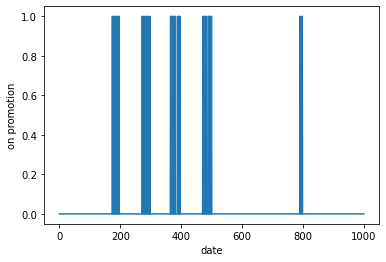

In [22]:
plt.xlabel('date')
plt.ylabel('on promotion')
assortment_train_data['onpromotion'].plot()
plt.show()


In [24]:
expr = 'unit_sales ~ ln_unit_sales_lag1 + work + weekend + holiday + onpromotion + assortment_1 + assortment_2 \
      + assortment_3 + assortment_4 + assortment_5 + assortment_6 + assortment_7 + assortment_8 + assortment_9 + assortment_10  '
y_train, x_train = dmatrices(expr, assortment_train_data, return_type='dataframe')

In [25]:
x_train

,Intercept,ln_unit_sales_lag1,work,weekend,holiday,onpromotion,assortment_1,assortment_2,assortment_3,assortment_4,assortment_5,assortment_6,assortment_7,assortment_8,assortment_9,assortment_10
1,1.0,1.098612,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.693147,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.693147,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,1.0,2.079442,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1.0,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
996,1.0,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
997,1.0,1.098612,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
998,1.0,0.693147,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [26]:
print(y_train)

     unit_sales
1           2.0
2           1.0
3           2.0
4           8.0
5           3.0
..          ...
995         1.0
996         3.0
997         2.0
998         6.0
999         3.0

[999 rows x 1 columns]


**Conduct GP1 regression**

In [27]:
gen_poisson_gp1 = sm.GeneralizedPoisson(y_train, x_train, p=1)
gen_poisson_gp1_results = gen_poisson_gp1.fit()

Optimization terminated successfully.
         Current function value: 2.116315
         Iterations: 21
         Function evaluations: 24
         Gradient evaluations: 24


c:\ProgramData\Anaconda3\envs\tensorflow-python38\lib\site-packages\statsmodels\base\model.py:592: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '


In [28]:
print(gen_poisson_gp1_results.summary())

                    GeneralizedPoisson Regression Results                     
Dep. Variable:             unit_sales   No. Observations:                  999
Model:             GeneralizedPoisson   Df Residuals:                      985
Method:                           MLE   Df Model:                           13
Date:                Sun, 10 Jul 2022   Pseudo R-squ.:                  0.1461
Time:                        00:12:38   Log-Likelihood:                -2114.2
converged:                       True   LL-Null:                       -2476.1
Covariance Type:            nonrobust   LLR p-value:                2.896e-146
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              1.3429        nan        nan        nan         nan         nan
ln_unit_sales_lag1    -0.0502        nan        nan        nan         nan         nan
work                

**AIC**

In [29]:
gen_poisson_gp1_results.aic

4258.396407176771

In [30]:
gp1_regression_prediction = np.exp(x_train.dot(gen_poisson_gp1_results.params[:-1]))

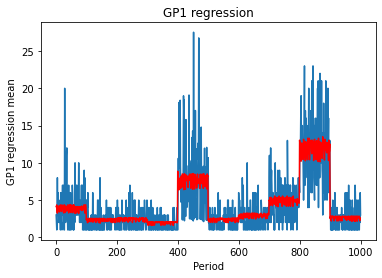

In [31]:
#Plot the number of unit sales in each period
plt.xlabel('Period')
plt.ylabel('Unit sales')
assortment_train_data['unit_sales'].plot()

plt.xlabel('Period')
plt.ylabel('GP1 regression mean')
plt.title("GP1 regression")
plt.plot(range(len(gp1_regression_prediction)),gp1_regression_prediction,'-r')

plt.show()

**MAE**

In [32]:
np.abs(gp1_regression_prediction - assortment_train_data['unit_sales'][1:]).mean()


1.8590779266689599

**Conduct GP1 HMM with covariate training**

In [33]:
cor = 'unit_sales ~ onpromotion + DayToWagePaid '
y, covariate = dmatrices(cor, assortment_train_data, return_type='dataframe')
#del covariate['DayToWagePaid']

In [34]:
k_regimes = 2
extra_params_names = []

for regime_num in range(1, k_regimes):
    for param_name in x_train.columns:
        extra_params_names.append(param_name+'_R'+str(regime_num))

for k in range(k_regimes-1):
    extra_params_names.append('Initial state_'+str(k))

for regime_num in range(k_regimes):
#    extra_params_names.append("Intercept_"+str(regime_num))
    for param_name in covariate.columns:
        extra_params_names.append(param_name+"_"+str(regime_num))
    

#for i in range(k_regimes):
#    for j in range(k_regimes-2):
#        extra_params_names.append('q_'+str(i)+str(j))

for k in range(k_regimes):
    extra_params_names.append('alpha '+ str(k))

In [35]:
gp1_hmm = GP1HMM(endog=y_train, exog=x_train, covariate=covariate,
                        k_regimes=k_regimes,length=[len(y_train)],
                        extra_params_names=extra_params_names)

params = gp1_hmm.start_params
params[:-2] = params[:-2] /1000


In [36]:
gp1_hmm.start_params.shape[0]
const1 = np.zeros([gp1_hmm.start_params.shape[0]])
const1[-2:] = 1
const1[-1] = 0

const2 = np.zeros([gp1_hmm.start_params.shape[0]])
const2[-1] = 1


In [37]:
constraint1 = opt.LinearConstraint(list(const1), 0, 1)
constraint2 = opt.LinearConstraint(list(const2), 0, 1)

In [38]:
res=opt.minimize(gp1_hmm.nloglikeopt,params, method='Nelder-Mead',constraints = (constraint1, constraint2))

#gp1_hmm_results = gp1_hmm.fit(method='bfgs', maxiter=400)

C:\Users\s9421\AppData\Roaming\Python\Python38\site-packages\scipy\optimize\_minimize.py:521: RuntimeWarning: Method Nelder-Mead cannot handle constraints nor bounds.
  warn('Method %s cannot handle constraints nor bounds.' % method,


ITER=1 ll=5785.898688685079
ITER=2 ll=5785.825902121069
ITER=3 ll=5785.787703301046
ITER=4 ll=5785.847346133232
ITER=5 ll=5785.88673087914
ITER=6 ll=5785.889202478854
ITER=7 ll=5785.89700578448
ITER=8 ll=5785.891748509941
ITER=9 ll=5785.895472954484
ITER=10 ll=5785.895298035556
ITER=11 ll=5785.896522596811
ITER=12 ll=5785.884692280481
ITER=13 ll=5785.895447920539
ITER=14 ll=5785.893898257708
ITER=15 ll=5785.888924202297
ITER=16 ll=5785.877372549179
ITER=17 ll=5785.894722979781
ITER=18 ll=5785.825902133518
ITER=19 ll=5785.787703314723
ITER=20 ll=5785.8473461456815
ITER=21 ll=5785.88673087914
ITER=22 ll=5785.889202478854
ITER=23 ll=5785.89700578448
ITER=24 ll=5785.89174852239
ITER=25 ll=5785.895472954484
ITER=26 ll=5785.895298035556
ITER=27 ll=5785.896522596811
ITER=28 ll=5785.884692280481
ITER=29 ll=5785.895447920539
ITER=30 ll=5785.893898257708
ITER=31 ll=5785.888924202297
ITER=32 ll=5785.877372549179
ITER=33 ll=5785.894722979781
ITER=34 ll=5785.898688685079
ITER=35 ll=5785.89868868507

In [39]:
for i in range(2):
    res=opt.minimize(gp1_hmm.nloglikeopt,res.x, method='Nelder-Mead')

ITER=8201 ll=2306.7769287307965
ITER=8202 ll=2306.410421250612
ITER=8203 ll=2305.187962602352
ITER=8204 ll=2307.348627376422
ITER=8205 ll=2306.7719498531073
ITER=8206 ll=2307.045119095776
ITER=8207 ll=2306.783179246122
ITER=8208 ll=2306.688845201901
ITER=8209 ll=2306.996053239622
ITER=8210 ll=2306.803761730971
ITER=8211 ll=2307.378032072548
ITER=8212 ll=2306.849514528251
ITER=8213 ll=2306.8603321950613
ITER=8214 ll=2307.127800617436
ITER=8215 ll=2306.6507705093354
ITER=8216 ll=2306.7290725777766
ITER=8217 ll=2306.8908070025063
ITER=8218 ll=2306.9432215963448
ITER=8219 ll=2304.836990796698
ITER=8220 ll=2307.6913609771227
ITER=8221 ll=2306.665685479671
ITER=8222 ll=2307.0594342984286
ITER=8223 ll=2306.8669052168675
ITER=8224 ll=2306.8815892528373
ITER=8225 ll=2306.705221862842
ITER=8226 ll=2306.7643106590945
ITER=8227 ll=2306.626905528004
ITER=8228 ll=2306.577798797489
ITER=8229 ll=2306.7376015352274
ITER=8230 ll=2306.9397614272702
ITER=8231 ll=2306.7358241290904
ITER=8232 ll=2307.289463

C:\Users\s9421\AppData\Local\Temp/ipykernel_24524/3060495314.py:4: RuntimeWarning: invalid value encountered in power
  return ( 1/math.exp((mu + alpha*y) ) * mu * ( (mu + alpha*y)**(y-1) ) ) / (math.factorial(int(y)))
C:\Users\s9421\AppData\Local\Temp/ipykernel_24524/4023834320.py:298: RuntimeWarning: invalid value encountered in less
  if prob_y_t < self.EPS:


ITER=10997 ll=2096.110501141905
ITER=10998 ll=2098.3632018519975
ITER=10999 ll=2096.6384861513925
ITER=11000 ll=2098.0085172531303
ITER=11001 ll=2096.0354525785274
ITER=11002 ll=2097.122274517229
ITER=11003 ll=2094.7847054837384
ITER=11004 ll=2093.5268353420197
ITER=11005 ll=2096.643402111352
ITER=11006 ll=2095.8145075809443
ITER=11007 ll=2097.1197491073726
ITER=11008 ll=2097.6592077082137
ITER=11009 ll=2097.953499642489
ITER=11010 ll=2095.018173831306
ITER=11011 ll=2095.4635293360607
ITER=11012 ll=nan
ITER=11013 ll=2097.2911855509374
ITER=11014 ll=2094.5832622819376
ITER=11015 ll=2097.063975997664
ITER=11016 ll=2095.408856391613
ITER=11017 ll=2096.855250452033
ITER=11018 ll=2095.7997207748394
ITER=11019 ll=2095.156755600199
ITER=11020 ll=2095.6067627409143
ITER=11021 ll=2097.653634059933
ITER=11022 ll=2096.1304154146146
ITER=11023 ll=2094.6947479240275
ITER=11024 ll=2095.285980905745
ITER=11025 ll=nan
ITER=11026 ll=2096.5676157817325
ITER=11027 ll=2095.4204569269255
ITER=11028 ll=2094

In [40]:
print(res)

 final_simplex: (array([[ 0.74800628,  0.057978  ,  0.61916085, ..., -0.07669343,
        -0.09972395,  0.08988886],
       [ 0.743334  ,  0.05868533,  0.61918872, ..., -0.08634068,
        -0.10040578,  0.09019822],
       [ 0.74871862,  0.05739604,  0.61589378, ..., -0.08041909,
        -0.10041377,  0.09000402],
       ...,
       [ 0.74437038,  0.06060406,  0.62326224, ..., -0.07691685,
        -0.10022845,  0.09035694],
       [ 0.74048054,  0.05959306,  0.62290463, ..., -0.07572539,
        -0.10055754,  0.08930997],
       [ 0.75414601,  0.0510668 ,  0.62214794, ..., -0.08424355,
        -0.10030644,  0.08966994]]), array([1985.98156974, 1985.98558933, 1985.99489324, 1985.99655819,
       1986.01381267, 1986.01485929, 1986.01597073, 1986.01881288,
       1986.02504326, 1986.02579099, 1986.02584175, 1986.02803876,
       1986.03735608, 1986.04121271, 1986.04471719, 1986.04513072,
       1986.04838941, 1986.04849655, 1986.0486731 , 1986.05771419,
       1986.05786225, 1986.0621174

In [41]:
res.x

array([  0.74800628,   0.057978  ,   0.61916085,   0.49282624,
         0.238942  ,   0.24194955,  -0.37512599,  -0.30401594,
        -0.30995201,  -0.08104382,   0.04654275,  -0.16467663,
        -0.29326084,   0.70082979,   0.74371184,   0.07497332,
        -0.39764906,  -0.06893308,   2.19221494,   2.05022336,
         2.12954983,   0.08797038,  -0.24909612,  -1.06023315,
        -1.18357802,  -1.37397025,   0.62657643,  -1.25003627,
        -0.64751488,  -0.49996665,   0.86679661,  -1.1380384 ,
         0.27338181,   6.5386377 ,   2.3432741 , -34.75454106,
         0.38373726,  -2.5402444 ,  -0.07669343,  -0.09972395,
         0.08988886])

In [42]:
gp1_hmm.sort()
'''(gp1_hmm_results.params = gp1_hmm.beta_matrix.flatten()
gp1_hmm_results.params = np.append(gp1_hmm_results.params, gp1_hmm.initial_state_matrix.flatten())
gp1_hmm_results.params = np.append(gp1_hmm_results.params, gp1_hmm.covariate_beta_matrix.flatten())
if k_regimes>2:
    gp1_hmm_results.params = np.append(gp1_hmm_results.params, gp1_hmm.q_matrix.flatten()))'''
    
print('Mean of transition matrix:')
print(np.mean(gp1_hmm.gamma_matrix,axis = 0))

Mean of transition matrix:
[[0.4438107  0.5561893 ]
 [0.94096383 0.05903617]]


**Emission**

In [43]:
for k in range(k_regimes):
    for i  in range(gp1_hmm.beta_matrix.shape[1]):
        print(x_train.columns[i],str(k + 1)+':',np.round(gp1_hmm.beta_matrix[k][i], decimals=2),end='. ')
    print('')

Intercept 1: -0.4. ln_unit_sales_lag1 1: -0.07. work 1: 2.2. weekend 1: 2.06. holiday 1: 2.13. onpromotion 1: 0.09. assortment_1 1: -0.26. assortment_2 1: -1.05. assortment_3 1: -1.19. assortment_4 1: -1.36. assortment_5 1: 0.62. assortment_6 1: -1.26. assortment_7 1: -0.65. assortment_8 1: -0.5. assortment_9 1: 0.87. assortment_10 1: -1.15. 
Intercept 2: 0.74. ln_unit_sales_lag1 2: 0.06. work 2: 0.62. weekend 2: 0.49. holiday 2: 0.24. onpromotion 2: 0.24. assortment_1 2: -0.38. assortment_2 2: -0.31. assortment_3 2: -0.32. assortment_4 2: -0.08. assortment_5 2: 0.05. assortment_6 2: -0.18. assortment_7 2: -0.29. assortment_8 2: 0.7. assortment_9 2: 0.75. assortment_10 2: 0.08. 


**Transition Matrix**

In [44]:
for k in range(k_regimes):
    for i  in range(gp1_hmm.covariate_beta_matrix.shape[1]):
        print(covariate.columns[i],str(k + 1)+':',np.round(gp1_hmm.covariate_beta_matrix[k][i], decimals=2),end='. ')
    print('')

Intercept 1: 0.43. onpromotion 1: -2.56. DayToWagePaid 1: -0.09. 
Intercept 2: 6.56. onpromotion 2: 2.33. DayToWagePaid 2: -34.82. 


In [45]:
gp1_hmm.decode()

In [46]:
state_specific_mu = np.zeros([y_train.shape[0]])
for t in range(y_train.shape[0]):
    if (gp1_hmm.decode_matrix[t] == 1):
        state_specific_mu[t] = gp1_hmm.mu_matrix[t][0]/(1-gp1_hmm.alpha[0])
    elif(gp1_hmm.decode_matrix[t] == 2):
        state_specific_mu[t] = gp1_hmm.mu_matrix[t][1]/(1-gp1_hmm.alpha[1])
    else:
        state_specific_mu[t] = gp1_hmm.mu_matrix[t][2]/(1-gp1_hmm.alpha[2])

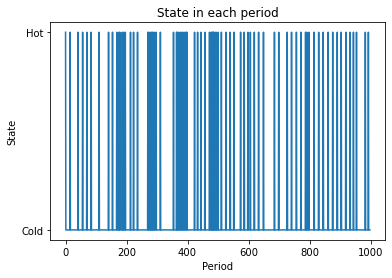

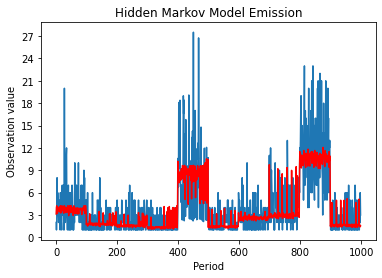

In [47]:
from matplotlib.ticker import MaxNLocator

#Plot the state each month
plt.xlabel('Period')
plt.ylabel('State')
plt.title("State in each period")
plt.yticks([1,2],['Cold','Hot'])
plt.plot(range(y_train.shape[0]),gp1_hmm.decode_matrix)
plt.show()

#Plot the number of strikes starting each month
plt.xlabel('Period')
plt.ylabel('Observation value')
plt.title("Hidden Markov Model Emission")
plt.plot(range(y_train.shape[0]),assortment_train_data['unit_sales'][1:])
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))

#Plot the mu_2 each month
plt.plot(range(y_train.shape[0]),state_specific_mu,'-r')

plt.show()

**MAE**

In [48]:
np.abs(state_specific_mu-assortment_train_data['unit_sales'][1:]).mean()

1.9663148112174278

**AIC**

In [49]:
int((-(gp1_hmm.ll_history[-1])*2+gp1_hmm.start_params.shape[0]*2))

4053

In [50]:
gp1_hmm.alpha

array([[-0.10040578],
       [ 0.09019822]])

**Test data evaluation**

In [53]:
expr_test = 'unit_sales ~ ln_unit_sales_lag1 + work + weekend + holiday + onpromotion + assortment_1 + assortment_2 \
      + assortment_3 + assortment_4 + assortment_5 + assortment_6 + assortment_7 + assortment_8 + assortment_9 + assortment_10  '
y_train, x_train = dmatrices(expr, assortment_train_data, return_type='dataframe')
y_test, x_test = dmatrices(expr_test, assortment_test_data, return_type='dataframe')

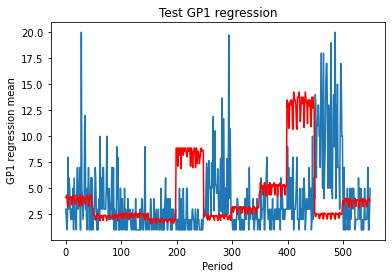

In [54]:
test_gp1_regression_prediction = np.exp(x_test.dot(gen_poisson_gp1_results.params[:-1]))

#Plot the number of unit sales in each period
plt.xlabel('Period')
plt.ylabel('Unit sales')
assortment_test_data['unit_sales'].plot()

plt.xlabel('Period')
plt.ylabel(' GP1 regression mean')
plt.title("Test GP1 regression")
plt.plot(range(len(test_gp1_regression_prediction)),test_gp1_regression_prediction,'-r')

plt.show()

In [55]:
np.abs(test_gp1_regression_prediction - assortment_test_data['unit_sales'][1:]).mean()


3.5187485108428227

In [59]:
cor = 'unit_sales ~ onpromotion + DayToWagePaid '
y, covariate_test = dmatrices(cor, assortment_test_data, return_type='dataframe')
#del covariate['DayToWagePaid']

In [60]:
gp1_hmm_test = GP1HMM(endog=y_test, exog=x_test, covariate=covariate_test,
                        k_regimes=k_regimes,length=[len(y_test)],
                        extra_params_names=extra_params_names)


In [61]:
params = res.x
gp1_hmm_test.nloglikeopt(params)

ITER=1 ll=1698.5837821394152


1698.5837821394152

In [62]:
gp1_hmm_test.decode()

state_specific_mu_test = np.zeros([y_test.shape[0]])
for t in range(y_test.shape[0]):
    if (gp1_hmm.decode_matrix[t] == 1):
        state_specific_mu_test[t] = gp1_hmm_test.mu_matrix[t][0]/(1-gp1_hmm_test.alpha[0])
    elif(gp1_hmm.decode_matrix[t] == 2):
        state_specific_mu_test[t] = gp1_hmm_test.mu_matrix[t][1]/(1-gp1_hmm_test.alpha[1])
    else:
        state_specific_mu_test[t] = gp1_hmm_test.mu_matrix[t][2]/(1-gp1_hmm_test.alpha[2])

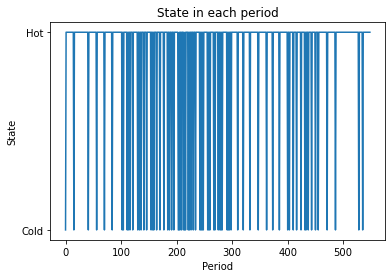

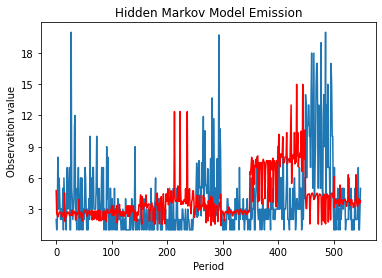

In [63]:
from matplotlib.ticker import MaxNLocator

#Plot the state each month
plt.xlabel('Period')
plt.ylabel('State')
plt.title("State in each period")
plt.yticks([1,2],['Cold','Hot'])
plt.plot(range(y_test.shape[0]),gp1_hmm_test.decode_matrix)
plt.show()

#Plot the number of strikes starting each month
plt.xlabel('Period')
plt.ylabel('Observation value')
plt.title("Hidden Markov Model Emission")
plt.plot(range(y_test.shape[0]),assortment_test_data['unit_sales'][1:])
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))

#Plot the mu_2 each month
plt.plot(range(y_test.shape[0]),state_specific_mu_test,'-r')

plt.show()

In [64]:
np.abs(state_specific_mu_test - assortment_test_data['unit_sales'][1:]).mean()

2.8202702198847156